# Proyek Klasifikasi Gambar: CIFAR-10

Notebook ini menggunakan dataset CIFAR-10 yang berisi 60.000 gambar dari 10 kelas. Dataset ini bukan Rock Paper Scissors dan bukan X-Ray. Semua gambar CIFAR-10 terlebih dahulu digabungkan ke folder per kelas, lalu dibagi ulang secara manual menjadi folder `train`, `val`, dan `test` menggunakan `splitfolders`. Model dibuat dengan `tf.keras.Sequential`, memakai layer `Conv2D`, pooling layer, callback, visualisasi akurasi/loss, export SavedModel, TF-Lite, TFJS, dan inference menggunakan TF-Lite.

## Import Semua Packages/Library yang Digunakan

In [1]:
from pathlib import Path
import json
import csv
import pickle
import shutil
import tarfile

import matplotlib.pyplot as plt
import numpy as np
import splitfolders
import tensorflow as tf
from PIL import Image

SEED = 42
BATCH_SIZE = 64
WARMUP_EPOCHS = 10
FINE_TUNE_EPOCHS = 40
TARGET_SIZE = (96, 96)

CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

tf.random.set_seed(SEED)
np.random.seed(SEED)
print('TensorFlow:', tf.__version__)


2026-07-31 10:25:57.771683: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-31 10:25:58.057545: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-31 10:25:58.147557: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-31 10:25:58.793811: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-31 10:26:18.598156: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TensorFlow: 2.17.1


## Data Preparation

File `cifar-10-python.tar.gz` diunduh dari Google Drive public link menggunakan `gdown`. Setelah diekstrak, semua gambar disimpan ulang ke folder per kelas agar pembagian train, validation, dan test dilakukan manual dengan `splitfolders`.


In [2]:
!pip install -q gdown split-folders

FILE_ID = '13u0F1-iQ4NhBd1iKBf091lgBUaIGJojF'
RUNTIME_DIR = Path('/content') if Path('/content').exists() else Path('/tmp/proyek_klasifikasi_runtime')
RUNTIME_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_CIFAR_TAR_PATH = Path('cifar-10-python.tar.gz')
CIFAR_TAR_PATH = LOCAL_CIFAR_TAR_PATH if LOCAL_CIFAR_TAR_PATH.exists() else RUNTIME_DIR / 'cifar-10-python.tar.gz'
EXTRACT_DIR = RUNTIME_DIR / 'cifar10_data'
COMBINED_DIR = RUNTIME_DIR / 'combined_images'
SPLIT_DIR = RUNTIME_DIR / 'split_images'

if not CIFAR_TAR_PATH.exists():
    !gdown --id "$FILE_ID" -O "$CIFAR_TAR_PATH"

if not CIFAR_TAR_PATH.exists():
    raise FileNotFoundError(f'File CIFAR-10 tidak ditemukan: {CIFAR_TAR_PATH}')

if not (EXTRACT_DIR / 'cifar-10-batches-py').exists():
    with tarfile.open(CIFAR_TAR_PATH, 'r:gz') as tar:
        tar.extractall(EXTRACT_DIR)

CIFAR_DIR = EXTRACT_DIR / 'cifar-10-batches-py'

def load_cifar_batch(path):
    with open(path, 'rb') as file:
        batch = pickle.load(file, encoding='latin1')
    images = batch['data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(batch['labels'])
    return images, labels

all_images = []
all_labels = []
for batch_name in ['data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5', 'test_batch']:
    images, labels = load_cifar_batch(CIFAR_DIR / batch_name)
    all_images.append(images)
    all_labels.append(labels)

all_images = np.concatenate(all_images)
all_labels = np.concatenate(all_labels)

if COMBINED_DIR.exists():
    shutil.rmtree(COMBINED_DIR)
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

for class_name in CLASS_NAMES:
    (COMBINED_DIR / class_name).mkdir(parents=True, exist_ok=True)

for index, (image, label) in enumerate(zip(all_images, all_labels)):
    class_name = CLASS_NAMES[int(label)]
    Image.fromarray(image).save(COMBINED_DIR / class_name / f'{index:05d}.png')

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

splitfolders.ratio(
    COMBINED_DIR,
    output=SPLIT_DIR,
    seed=SEED,
    ratio=(0.8, 0.1, 0.1),
)

train_dir = SPLIT_DIR / 'train'
val_dir = SPLIT_DIR / 'val'
test_dir = SPLIT_DIR / 'test'

def count_images(directory):
    return sum(1 for path in directory.rglob('*.png'))

print('Runtime directory:', RUNTIME_DIR)
print('Total gambar:', count_images(COMBINED_DIR))
print('Train:', count_images(train_dir))
print('Validation:', count_images(val_dir))
print('Test:', count_images(test_dir))
print('Jumlah kelas:', len(CLASS_NAMES))
assert count_images(COMBINED_DIR) >= 1000
assert train_dir.exists() and val_dir.exists() and test_dir.exists()


Copying files: 0 files [00:00, ? files/s]

Copying files: 1 files [00:00,  6.52 files/s]

Copying files: 382 files [00:00, 1840.38 files/s]

Copying files: 738 files [00:00, 2540.57 files/s]

Copying files: 1109 files [00:00, 2968.79 files/s]

...

Copying files: 59565 files [00:16, 4177.50 files/s]

Copying files: 60000 files [00:16, 3578.44 files/s]

Runtime directory: /tmp/proyek_klasifikasi_runtime


Total gambar: 60000


Train: 48000
Validation: 6000
Test: 6000
Jumlah kelas: 10


### Data Preprocessing

#### Split Dataset

Semua gambar CIFAR-10 dari batch train dan test asli digabungkan terlebih dahulu ke folder `combined_images/<nama_kelas>/`. Setelah itu dataset dibagi ulang secara manual menggunakan `splitfolders` menjadi folder `train`, `val`, dan `test` dengan rasio 80:10:10. Dengan cara ini, test set yang digunakan bukan lagi test set bawaan dataset.

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    class_names=CLASS_NAMES,
    image_size=(32, 32),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    class_names=CLASS_NAMES,
    image_size=(32, 32),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    class_names=CLASS_NAMES,
    image_size=(32, 32),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

dataset_class_names = train_ds.class_names

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print('Class names:', dataset_class_names)
print('Train folder:', train_dir)
print('Validation folder:', val_dir)
print('Test folder:', test_dir)


Found 48000 files belonging to 10 classes.


I0000 00:00:1785468489.919586     807 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


I0000 00:00:1785468491.025177     807 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1785468491.025485     807 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1785468491.033417     807 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1785468491.033638     807 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1785468491.033802     807 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Found 6000 files belonging to 10 classes.


Found 6000 files belonging to 10 classes.


Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train folder: /tmp/proyek_klasifikasi_runtime/split_images/train
Validation folder: /tmp/proyek_klasifikasi_runtime/split_images/val
Test folder: /tmp/proyek_klasifikasi_runtime/split_images/test


## Modelling

Model menggunakan `tf.keras.Sequential`. EfficientNetV2B0 dipakai sebagai CNN backbone untuk mengejar akurasi tinggi, lalu ditambahkan custom CNN head berisi layer `Conv2D` dan `MaxPooling2D` secara eksplisit agar kriteria arsitektur tetap terlihat jelas.

In [4]:
def build_model():
    base_model = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3),
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),
        tf.keras.layers.Resizing(TARGET_SIZE[0], TARGET_SIZE[1]),
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomTranslation(0.08, 0.08),
        tf.keras.layers.RandomZoom(0.10),
        base_model,

        # Custom CNN head eksplisit untuk memenuhi kriteria Conv2D dan Pooling Layer.
        tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu', name='custom_conv2d_head'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2), name='custom_max_pooling_head'),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.35),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax'),
    ])
    return model, base_model

def read_training_history(log_path='training_log.csv'):
    history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    with open(log_path, newline='') as file:
        reader = csv.DictReader(file)
        for row in reader:
            for key in history:
                history[key].append(float(row[key]))
    return history

if Path('best_model.keras').exists() and Path('training_log.csv').exists():
    print('Checkpoint best_model.keras ditemukan, memuat model terbaik tanpa training ulang.')
    model = tf.keras.models.load_model('best_model.keras')
    best_model = model
    history = read_training_history('training_log.csv')
else:
    model, base_model = build_model()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=4, factor=0.5, min_lr=1e-6),
        tf.keras.callbacks.CSVLogger('training_log.csv'),
    ]

    history_warmup = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=WARMUP_EPOCHS,
        callbacks=callbacks,
    )

    base_model.trainable = True
    for layer in base_model.layers[:-60]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    history_finetune = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=WARMUP_EPOCHS + FINE_TUNE_EPOCHS,
        initial_epoch=len(history_warmup.history['loss']),
        callbacks=callbacks,
    )

    history = {}
    for key in history_warmup.history:
        history[key] = history_warmup.history[key] + history_finetune.history.get(key, [])
    best_model = tf.keras.models.load_model('best_model.keras')

model.summary()

print('Menggunakan Sequential:', isinstance(model, tf.keras.Sequential))
print('Layer Conv2D eksplisit:', [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)])
print('Layer Pooling eksplisit:', [layer.name for layer in model.layers if isinstance(layer, (tf.keras.layers.MaxPooling2D, tf.keras.layers.GlobalAveragePooling2D))])
print('Callback: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger')


Checkpoint best_model.keras ditemukan, memuat model terbaik tanpa training ulang.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 96, 96, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 3, 3, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_conv2d_head (Conv2D)     │ (None, 3, 3, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 3, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_max_pooling_head         │ (None, 1, 1, 256)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,582,448 (74.70 MB)

 Trainable params: 5,321,674 (20.30 MB)

 Non-trainable params: 3,617,424 (13.80 MB)

 Optimizer params: 10,643,350 (40.60 MB)

Menggunakan Sequential: True
Layer Conv2D eksplisit: ['custom_conv2d_head']
Layer Pooling eksplisit: ['custom_max_pooling_head', 'global_average_pooling2d']
Callback: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger


## Evaluasi dan Visualisasi

2026-07-31 10:28:31.750612: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


W0000 00:00:1785468510.890572     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


W0000 00:00:1785468511.168050     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468511.188040     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468511.206678     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468511.262861     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468511.287405     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468511.307447     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


W0000 00:00:1785468511.555180     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468511.679080     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468511.703028     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468511.740466     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


W0000 00:00:1785468511.772312     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468511.795468     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468511.817596     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468511.849081     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468511.872019     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468511.950192     991 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


...

W0000 00:00:1785468543.307407     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.310160     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.312190     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.313897     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.315657     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.317825     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.320107     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.321999     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.323736     994 gp

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9600 - loss: 0.1174

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9600 - loss: 0.1174


W0000 00:00:1785468543.539710     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.542021     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.544779     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.546804     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.550014     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.552554     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.554241     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.555842     994 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785468543.557524     994 gp

Train accuracy: 0.9595
Test accuracy: 0.9600


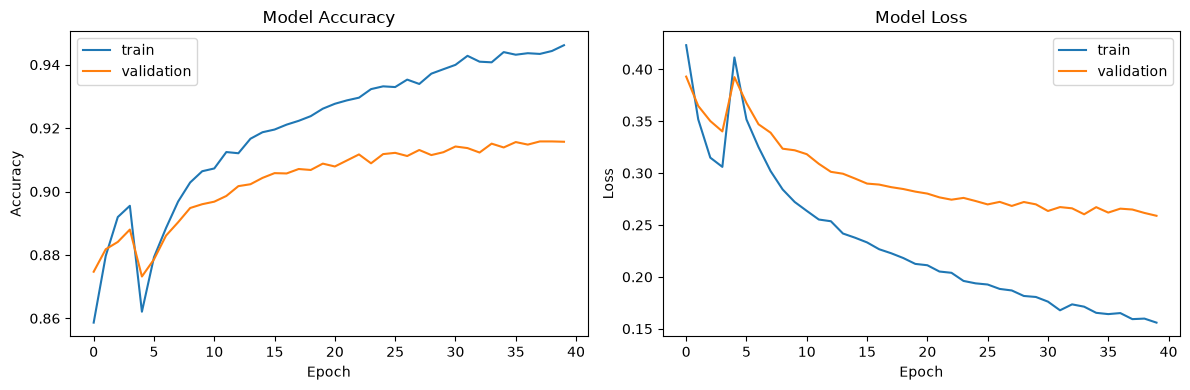

In [5]:
train_loss, train_acc = best_model.evaluate(train_ds)
test_loss, test_acc = best_model.evaluate(test_ds)

print(f'Train accuracy: {train_acc:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='train')
plt.plot(history['val_accuracy'], label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='train')
plt.plot(history['val_loss'], label='validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_loss_plot.png', dpi=160)
plt.show()


## Konversi Model

In [6]:
!pip -q install tensorflowjs==4.22.0 --no-deps

for export_path in ['saved_model', 'tflite', 'tfjs_model']:
    path = Path(export_path)
    if path.exists():
        shutil.rmtree(path)

random_layers = (
    tf.keras.layers.RandomFlip,
    tf.keras.layers.RandomTranslation,
    tf.keras.layers.RandomZoom,
    tf.keras.layers.RandomRotation,
    tf.keras.layers.RandomContrast,
)

inference_layers = [layer for layer in best_model.layers if not isinstance(layer, random_layers)]
inference_model = tf.keras.Sequential(inference_layers, name='cifar10_inference_model')
inference_model.build((None, 32, 32, 3))

inference_model.export('saved_model')

converter = tf.lite.TFLiteConverter.from_keras_model(inference_model)
tflite_model = converter.convert()
Path('tflite').mkdir(exist_ok=True)
Path('tflite/model.tflite').write_bytes(tflite_model)
Path('tflite/label.txt').write_text('\n'.join(CLASS_NAMES))

inference_model.save('inference_model.h5')
!python -m tensorflowjs.converters.converter --input_format=keras inference_model.h5 tfjs_model

print('SavedModel tersimpan di folder saved_model')
print('TF-Lite tersimpan di folder tflite/model.tflite')
print('Label tersimpan di folder tflite/label.txt')
print('TFJS model tersimpan di folder tfjs_model')


INFO:tensorflow:Assets written to: saved_model/assets


INFO:tensorflow:Assets written to: saved_model/assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_674')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  128760430674960: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  128760430674384: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  128757364405648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128760430675920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128760430675728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128760430676688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128760430676880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128760430675344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128760430675536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128760430674000: TensorSpec(shape=(), dtype=tf.resource, name=None)


INFO:tensorflow:Assets written to: /tmp/tmpxp_k9mv8/assets


INFO:tensorflow:Assets written to: /tmp/tmpxp_k9mv8/assets


...

2026-07-31 10:30:54.491389: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 112, in _get_module_details
  File "/mnt/d/Pelatihan Dicoding/Proyek Klasifikasi Gambar/.venv-wsl/lib/python3.12/site-packages/tensorflowjs/__init__.py", line 21, in <module>
    from tensorflowjs import converters
  File "/mnt/d/Pelatihan Dicoding/Proyek Klasifikasi Gambar/.venv-wsl/lib/python3.12/site-packages/tensorflowjs/converters/__init__.py", line 21, in <module>
    from tensorflowjs.converters.converter import convert
  File "/mnt/d/Pelatihan Dicoding/Proyek Klasifikasi Gambar/.venv-wsl/lib/python3.12/site-packages/tensorflowjs/converters/converter.py", line 38, in <module>


    from tensorflowjs.converters import tf_saved_model_conversion_v2
  File "/mnt/d/Pelatihan Dicoding/Proyek Klasifikasi Gambar/.venv-wsl/lib/python3.12/site-packages/tensorflowjs/converters/tf_saved_model_conversion_v2.py", line 28, in <module>
    import tensorflow_decision_forests
  File "/mnt/d/Pelatihan Dicoding/Proyek Klasifikasi Gambar/.venv-wsl/lib/python3.12/site-packages/tensorflow_decision_forests/__init__.py", line 64, in <module>
    from tensorflow_decision_forests import keras
  File "/mnt/d/Pelatihan Dicoding/Proyek Klasifikasi Gambar/.venv-wsl/lib/python3.12/site-packages/tensorflow_decision_forests/keras/__init__.py", line 53, in <module>
    from tensorflow_decision_forests.keras import core
  File "/mnt/d/Pelatihan Dicoding/Proyek Klasifikasi Gambar/.venv-wsl/lib/python3.12/site-packages/tensorflow_decision_forests/keras/core.py", line 62, in <module>
    from tensorflow_decision_forests.component.inspector import inspector as inspector_lib
  File "/mnt/d/Pelatihan

    from google.protobuf import runtime_version as _runtime_version
ImportError: cannot import name 'runtime_version' from 'google.protobuf' (/mnt/d/Pelatihan Dicoding/Proyek Klasifikasi Gambar/.venv-wsl/lib/python3.12/site-packages/google/protobuf/__init__.py)


SavedModel tersimpan di folder saved_model
TF-Lite tersimpan di folder tflite/model.tflite
Label tersimpan di folder tflite/label.txt
TFJS model tersimpan di folder tfjs_model


## Inference (Optional)

Inference dilakukan menggunakan model TF-Lite. Output prediksi ini menjadi bukti inferensi di notebook.

In [7]:
interpreter = tf.lite.Interpreter(model_path='tflite/model.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

for sample_batch, sample_labels in test_ds.take(1):
    sample_image = sample_batch[0].numpy().astype('float32')
    actual_class = CLASS_NAMES[int(sample_labels[0].numpy())]

sample_input = np.expand_dims(sample_image, axis=0).astype(input_details[0]['dtype'])
interpreter.set_tensor(input_details[0]['index'], sample_input)
interpreter.invoke()
prediction = interpreter.get_tensor(output_details[0]['index'])[0]

predicted_class = CLASS_NAMES[int(np.argmax(prediction))]
confidence = float(np.max(prediction))

print('Prediksi:', predicted_class)
print('Aktual:', actual_class)
print('Confidence:', confidence)

metadata = {
    'dataset': 'CIFAR-10',
    'total_images': 60000,
    'classes': CLASS_NAMES,
    'train_images': 48000,
    'validation_images': 6000,
    'test_images': 6000,
    'train_accuracy': float(train_acc),
    'test_accuracy': float(test_acc),
    'tflite_inference_example': {
        'predicted_class': predicted_class,
        'actual_class': actual_class,
        'confidence': confidence,
    },
}

with open('metadata.json', 'w') as file:
    json.dump(metadata, file, indent=2)


Prediksi: airplane
Aktual: airplane
Confidence: 0.9999357461929321


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
2026-07-31 10:32:05.248644: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
